In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the data
df = pd.read_csv('definitions_data.csv')
df.sample(5)

,Year,Author,Journal,Title,Article Definition,Procedural Definition Coder 1,Process Definintion Coder 1,Unsure Coder 1,Procedural Definition Coder 2,Process Definintion Coder 2,Unsure Coder 2,Include,Notes
108,2020,"Elcoro, M., Lattal, K. A., & Choromanski, M.",Mexican Journal of Behavior Analysis,Repeated operant response resurgence with a pe...,The most common definition of resurgence is th...,NaN,1.0,NaN,NaN,1.0,NaN,1,NaN
92,2018,"Nighbor, Tyler D.; Kincaid, Stephanie L.; O'He...",Journal of the Experimental Analysis of Behavior,Stimulus contributions to operant resurgence,"Resurgence, the recurrence of previously reinf...",NaN,1.0,NaN,NaN,1.0,NaN,1,NaN
7,1983,"Epstein, Robert",Behaviour Analysis Letters,Resurgence of previously reinforced behavior d...,"When, in a given situation, recently reinforc...",NaN,1.0,NaN,NaN,1.0,NaN,1,NaN
23,2009,"Podlesnik, Christopher A; Shahan, Timothy A",Learning & Behavior,Behavioral momentum and relapse of extinguishe...,Resurgence is characterized by the reappearanc...,NaN,1.0,NaN,NaN,1.0,NaN,1,NaN
60,2016,"Bouton, Mark E; Trask, Sydney",Learning & Behavior,Role of the discriminative properties of the r...,Resurgence is the return of an extinguished op...,NaN,1.0,NaN,NaN,1.0,NaN,1,NaN


In [3]:
# Clean and prepare the data
# Remove rows with missing definitions or years
df_clean = df.dropna(subset=['Article Definition', 'Year']).copy()
df_clean = df_clean[df_clean['Include']==1].reset_index(drop=True)

# Convert Year to numeric, handling any non-numeric values
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')
df_clean = df_clean.dropna(subset=['Year'])

# Basic text cleaning
df_clean['Article Definition'] = df_clean['Article Definition'].astype(str).str.strip()

In [4]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_clean['Article Definition'])
tfidf_embeddings = tfidf_matrix.toarray()

print(f"TF-IDF matrix shape: {tfidf_embeddings.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

# Show top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nTop 20 TF-IDF features:")
for i, feature in enumerate(feature_names[:50]):
    print(f"{i+1:2d}. {feature}")

TF-IDF matrix shape: (107, 376)
Number of features: 376

Top 20 TF-IDF features:
 1. additionally
 2. al
 3. alternative
 4. alternative behavior
 5. alternative reinforcement
 6. alternative reinforcers
 7. alternative responding
 8. alternative response
 9. alternative second
10. alternative source
11. amore
12. amore recently
13. animals
14. approach
15. associated
16. attention
17. available
18. baseline
19. behavior
20. behavior alternative
21. behavior discontinued
22. behavior extinction
23. behavior extinguished
24. behavior following
25. behavior longer
26. behavior occurs
27. behavior pressing
28. behavior recovers
29. behavior reinforced
30. behavior reinforcement
31. behavior removed
32. behavior resulting
33. behavior returns
34. behavioral
35. behaviors
36. behaviors previously
37. called
38. called resurgence
39. case
40. change
41. characterized
42. characterized reappearance
43. commonly
44. complete
45. conditions
46. conditions alternative
47. conditions recently
48.

In [5]:
# Install and import sentence transformers
# !pip install sentence-transformers

from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast and effective

# Generate embeddings
print("Generating sentence transformer embeddings...")
sentence_embeddings = sentence_model.encode(df_clean['Article Definition'].tolist(), show_progress_bar=True)

print(f"Sentence transformer embeddings shape: {sentence_embeddings.shape}")
print(f"Embedding dimension: {sentence_embeddings.shape[1]}")

2025-06-28 16:53:51.651115: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Generating sentence transformer embeddings...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Sentence transformer embeddings shape: (107, 384)
Embedding dimension: 384


In [6]:
# BERT Embeddings
from transformers import AutoTokenizer, AutoModel
import torch

# Load BERT model and tokenizer
bert_model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
model = AutoModel.from_pretrained(bert_model_name)

# Function to get BERT embeddings
def get_bert_embeddings(texts, max_length=512):
    embeddings = []
    
    for text in texts:
        # Tokenize
        inputs = tokenizer(text, return_tensors='pt', max_length=max_length, truncation=True, padding=True)
        
        # Get embeddings
        with torch.no_grad():
            outputs = model(**inputs)
            # Use [CLS] token embedding (first token)
            embedding = outputs.last_hidden_state[:, 0, :].numpy().flatten()
            embeddings.append(embedding)
    
    return np.array(embeddings)

print("Generating BERT embeddings...")
bert_embeddings = get_bert_embeddings(df_clean['Article Definition'].tolist())

print(f"BERT embeddings shape: {bert_embeddings.shape}")
print(f"Embedding dimension: {bert_embeddings.shape[1]}")

Generating BERT embeddings...
BERT embeddings shape: (107, 768)
Embedding dimension: 768


In [7]:
# Universal Sentence Encoder (Modified version)
# !pip install tensorflow-hub

import tensorflow_hub as hub

# Load Universal Sentence Encoder (without tensorflow_text dependency)
try:
    use_model = hub.load('https://tfhub.dev/google/universal-sentence-encoder/4')
    print("Generating Universal Sentence Encoder embeddings...")
    use_embeddings = use_model(df_clean['Article Definition'].tolist()).numpy()
    print(f"USE embeddings shape: {use_embeddings.shape}")
    print(f"Embedding dimension: {use_embeddings.shape[1]}")
except Exception as e:
    print(f"Universal Sentence Encoder failed: {e}")
    print("Skipping this embedding method...")

Generating Universal Sentence Encoder embeddings...
USE embeddings shape: (107, 512)
Embedding dimension: 512


In [8]:
# Word2Vec with Averaging
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
import nltk
from nltk.corpus import stopwords

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Preprocess text for Word2Vec
def preprocess_text(text):
    # Tokenize and clean
    tokens = simple_preprocess(text, deacc=True)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    return tokens

# Prepare sentences for Word2Vec training
sentences = [preprocess_text(text) for text in df_clean['Article Definition']]

# Train Word2Vec model
print("Training Word2Vec model...")
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, epochs=10)

# Function to get document embeddings by averaging word vectors
def get_document_embedding(text, model, vector_size=100):
    tokens = preprocess_text(text)
    word_vectors = []
    
    for token in tokens:
        if token in model.wv:
            word_vectors.append(model.wv[token])
    
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(vector_size)

# Generate document embeddings
print("Generating Word2Vec document embeddings...")
w2v_embeddings = np.array([get_document_embedding(text, w2v_model) for text in df_clean['Article Definition']])

print(f"Word2Vec embeddings shape: {w2v_embeddings.shape}")
print(f"Embedding dimension: {w2v_embeddings.shape[1]}")

Training Word2Vec model...
Generating Word2Vec document embeddings...
Word2Vec embeddings shape: (107, 100)
Embedding dimension: 100


In [9]:
# Visualization functions
# Function to reduce dimensionality for visualization
def reduce_dimensions(embeddings, method='pca', n_components=2):
    if method == 'pca':
        reducer = PCA(n_components=n_components)
    elif method == 'tsne':
        reducer = TSNE(n_components=n_components, random_state=42, perplexity=min(30, len(embeddings)-1))
    else:
        raise ValueError("Method must be 'pca' or 'tsne'")
    
    return reducer.fit_transform(embeddings)

# Function to create temporal visualization
def plot_temporal_embeddings(embeddings, years, title, method='pca'):
    # Reduce dimensions
    reduced_embeddings = reduce_dimensions(embeddings, method=method)
    
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({
        'x': reduced_embeddings[:, 0],
        'y': reduced_embeddings[:, 1],
        'Year': years
    })
    
    # Create scatter plot
    fig = px.scatter(
        plot_df, x='x', y='y', color='Year',
        title=f'{title} - {method.upper()} Visualization',
        color_continuous_scale='viridis',
        hover_data=['Year']
    )
    
    fig.update_layout(
        width=800,
        height=600,
        showlegend=True
    )
    
    return fig

# Create visualizations for each embedding method
embedding_methods = {
    'TF-IDF': tfidf_embeddings,
    'Sentence Transformers': sentence_embeddings,
    'BERT': bert_embeddings,
    'Universal Sentence Encoder': use_embeddings,
    'Word2Vec': w2v_embeddings
}

years = df_clean['Year'].values

# Generate plots
for method_name, embeddings in embedding_methods.items():
    print(f"Creating visualization for {method_name}...")
    fig = plot_temporal_embeddings(embeddings, years, method_name, 'pca')
    fig.show()

Creating visualization for TF-IDF...


Creating visualization for Sentence Transformers...


Creating visualization for BERT...


Creating visualization for Universal Sentence Encoder...


Creating visualization for Word2Vec...


In [10]:
# # Visualization functions
# # Function to reduce dimensionality for visualization
# def reduce_dimensions(embeddings, method='pca', n_components=3):
#     if method == 'pca':
#         reducer = PCA(n_components=n_components)
#     elif method == 'tsne':
#         reducer = TSNE(n_components=n_components, random_state=42, perplexity=len(embeddings)-1)
#     else:
#         raise ValueError("Method must be 'pca' or 'tsne'")
    
#     return reducer.fit_transform(embeddings)

# # Function to create temporal visualization
# def plot_temporal_embeddings(embeddings, years, title, method='pca'):
#     # Reduce dimensions to 3D
#     reduced_embeddings = reduce_dimensions(embeddings, method=method, n_components=3)
    
#     # Create DataFrame for plotting
#     plot_df = pd.DataFrame({
#         'x': reduced_embeddings[:, 0],
#         'y': reduced_embeddings[:, 1],
#         'z': reduced_embeddings[:, 2],
#         'Year': years
#     })
    
#     # Create 3D scatter plot
#     fig = px.scatter_3d(
#         plot_df, x='x', y='y', z='z', color='Year',
#         title=f'{title} - {method.upper()} 3D Visualization',
#         color_continuous_scale='viridis',
#         hover_data=['Year']
#     )
    
#     fig.update_layout(
#         width=900,
#         height=700,
#         showlegend=True,
#         scene=dict(
#             xaxis_title=f'{method.upper()} Component 1',
#             yaxis_title=f'{method.upper()} Component 2',
#             zaxis_title=f'{method.upper()} Component 3'
#         )
#     )
    
#     return fig

# # Create visualizations for each embedding method
# embedding_methods = {
#     'TF-IDF': tfidf_embeddings,
#     'Sentence Transformers': sentence_embeddings,
#     'BERT': bert_embeddings,
#     'Universal Sentence Encoder': use_embeddings,
#     'Word2Vec': w2v_embeddings
# }

# years = df_clean['Year'].values

# # Generate plots
# for method_name, embeddings in embedding_methods.items():
#     print(f"Creating 3D visualization for {method_name}...")
#     fig = plot_temporal_embeddings(embeddings, years, method_name, 'tsne')
#     fig.show()

Analyzing temporal patterns for TF-IDF...
Analyzing temporal patterns for Sentence Transformers...
Analyzing temporal patterns for BERT...
Analyzing temporal patterns for Universal Sentence Encoder...
Analyzing temporal patterns for Word2Vec...


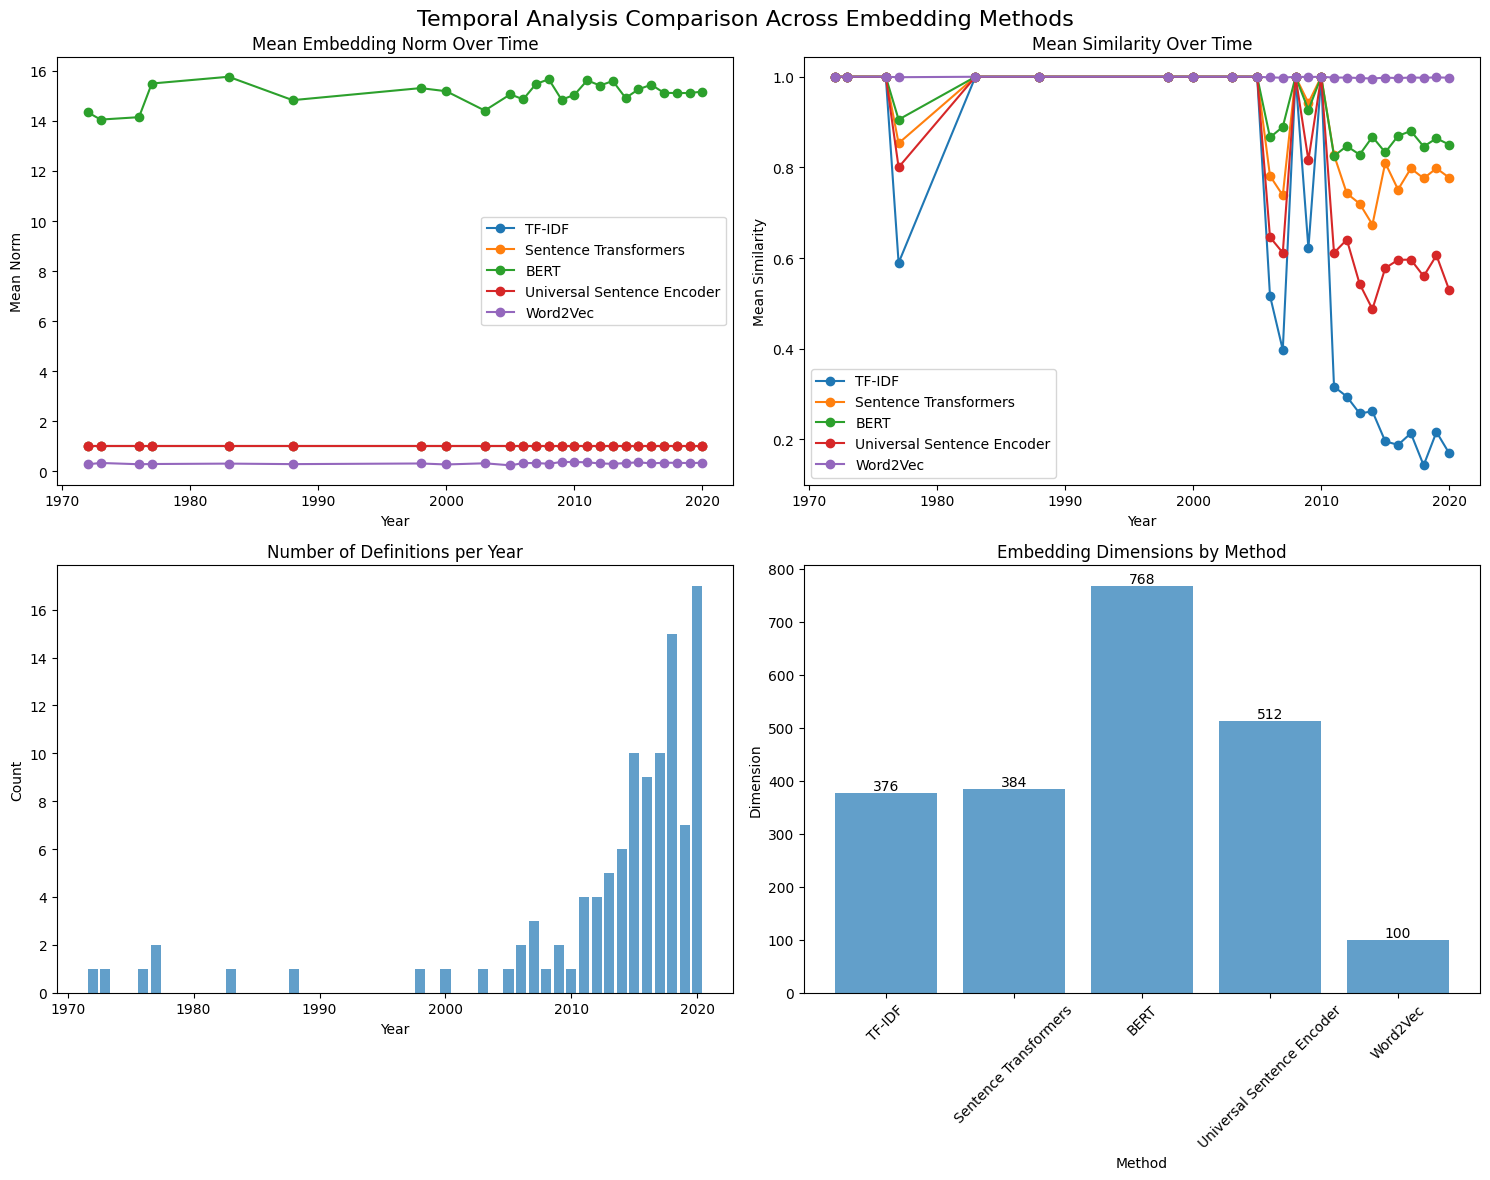

In [11]:
# Temporal analysis
def analyze_temporal_patterns(embeddings, years, method_name):
    """Analyze how embeddings change over time"""
    
    # Calculate year-wise statistics
    year_stats = {}
    for year in np.unique(years):
        year_mask = years == year
        year_embeddings = embeddings[year_mask]
        
        # Calculate statistics
        year_stats[year] = {
            'count': len(year_embeddings),
            'mean_norm': np.mean(np.linalg.norm(year_embeddings, axis=1)),
            'std_norm': np.std(np.linalg.norm(year_embeddings, axis=1)),
            'mean_similarity': np.mean(cosine_similarity(year_embeddings).flatten())
        }
    
    return year_stats

# Analyze all methods
temporal_analysis = {}
for method_name, embeddings in embedding_methods.items():
    print(f"Analyzing temporal patterns for {method_name}...")
    temporal_analysis[method_name] = analyze_temporal_patterns(embeddings, years, method_name)

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Temporal Analysis Comparison Across Embedding Methods', fontsize=16)

# Plot 1: Mean embedding norm over time
ax1 = axes[0, 0]
for method_name, stats in temporal_analysis.items():
    years_sorted = sorted(stats.keys())
    norms = [stats[year]['mean_norm'] for year in years_sorted]
    ax1.plot(years_sorted, norms, marker='o', label=method_name)
ax1.set_title('Mean Embedding Norm Over Time')
ax1.set_xlabel('Year')
ax1.set_ylabel('Mean Norm')
ax1.legend()

# Plot 2: Mean similarity over time
ax2 = axes[0, 1]
for method_name, stats in temporal_analysis.items():
    years_sorted = sorted(stats.keys())
    similarities = [stats[year]['mean_similarity'] for year in years_sorted]
    ax2.plot(years_sorted, similarities, marker='o', label=method_name)
ax2.set_title('Mean Similarity Over Time')
ax2.set_xlabel('Year')
ax2.set_ylabel('Mean Similarity')
ax2.legend()

# Plot 3: Number of definitions per year
ax3 = axes[1, 0]
year_counts = df_clean['Year'].value_counts().sort_index()
ax3.bar(year_counts.index, year_counts.values, alpha=0.7)
ax3.set_title('Number of Definitions per Year')
ax3.set_xlabel('Year')
ax3.set_ylabel('Count')

# Plot 4: Embedding dimension comparison
ax4 = axes[1, 1]
methods = list(embedding_methods.keys())
dimensions = [emb.shape[1] for emb in embedding_methods.values()]
bars = ax4.bar(methods, dimensions, alpha=0.7)
ax4.set_title('Embedding Dimensions by Method')
ax4.set_xlabel('Method')
ax4.set_ylabel('Dimension')
ax4.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, dim in zip(bars, dimensions):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(dim), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Calculating period similarity for TF-IDF...


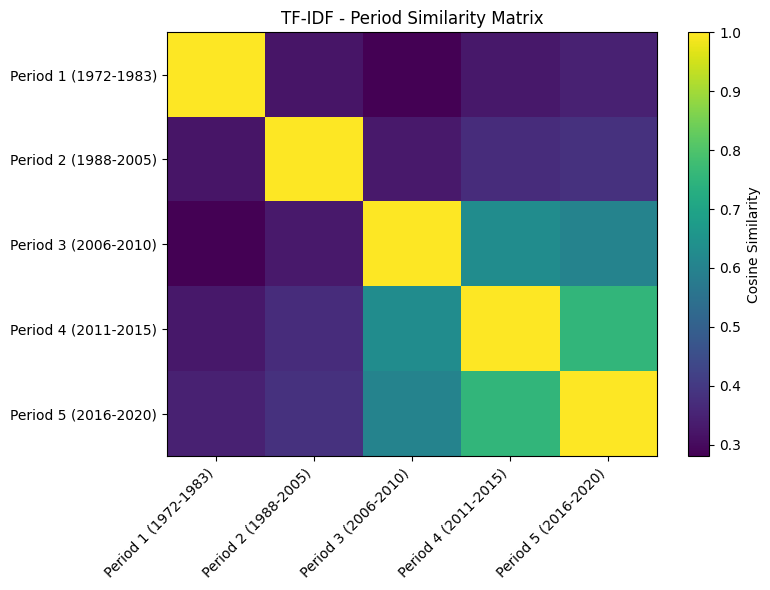

Calculating period similarity for Sentence Transformers...


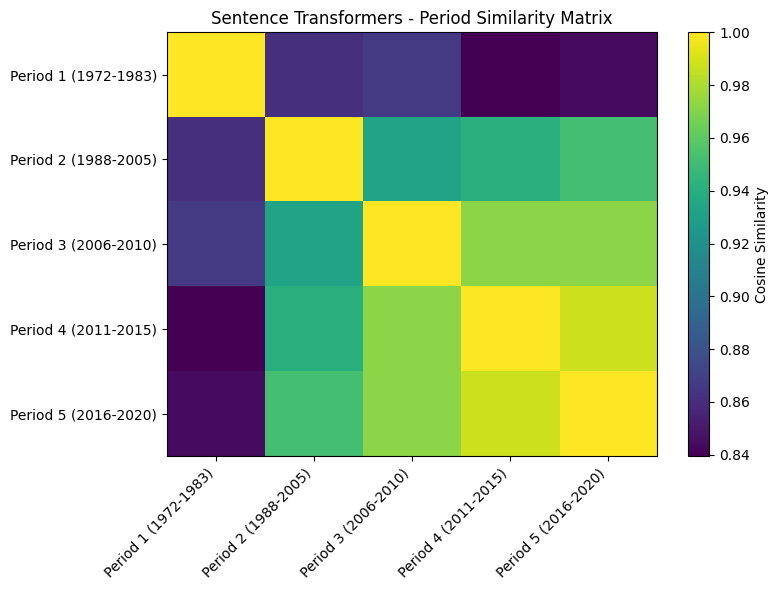

Calculating period similarity for BERT...


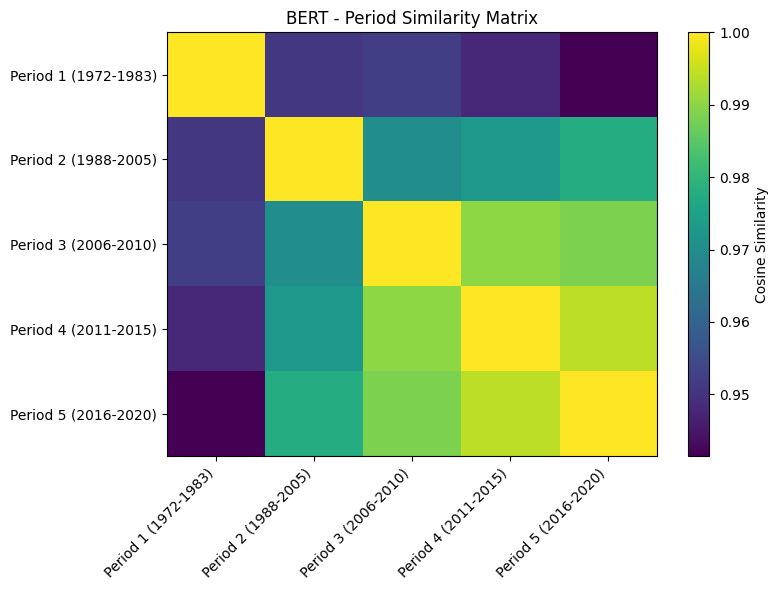

Calculating period similarity for Universal Sentence Encoder...


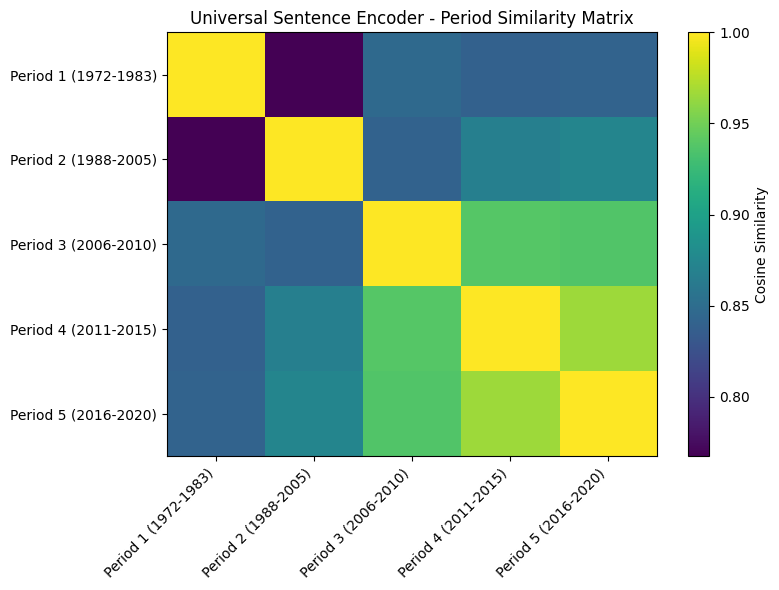

Calculating period similarity for Word2Vec...


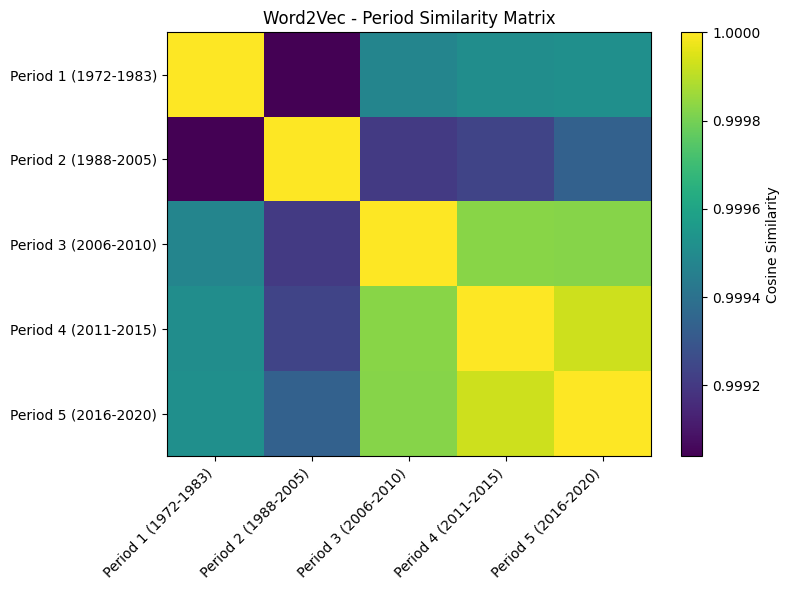

In [12]:
# Period similarity analysis
def calculate_period_similarity(embeddings, years, method_name):
    """Calculate similarity between different time periods"""
    
    # Define time periods (you can adjust these based on your data)
    unique_years = sorted(np.unique(years))
    if len(unique_years) >= 5:
        # Split into tenths
        tenth_size = len(unique_years) // 5
        periods = [
            unique_years[:tenth_size],
            unique_years[tenth_size:2*tenth_size],
            unique_years[2*tenth_size:3*tenth_size],
            unique_years[3*tenth_size:4*tenth_size],
            unique_years[4*tenth_size:]
        ]
    else:
        # Use individual years
        periods = [[year] for year in unique_years]
    
    # Calculate period embeddings
    period_embeddings = []
    period_labels = []
    
    for i, period_years in enumerate(periods):
        period_mask = np.isin(years, period_years)
        if np.sum(period_mask) > 0:
            period_emb = np.mean(embeddings[period_mask], axis=0)
            period_embeddings.append(period_emb)
            period_labels.append(f"Period {i+1} ({min(period_years)}-{max(period_years)})")
    
    if len(period_embeddings) > 1:
        # Calculate similarity matrix
        similarity_matrix = cosine_similarity(period_embeddings)
        
        # Create heatmap
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(similarity_matrix, cmap='viridis', aspect='auto', )
        
        # Add labels
        ax.set_xticks(range(len(period_labels)))
        ax.set_yticks(range(len(period_labels)))
        ax.set_xticklabels(period_labels, rotation=45, ha='right')
        ax.set_yticklabels(period_labels)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Cosine Similarity')
        
        ax.set_title(f'{method_name} - Period Similarity Matrix')
        plt.tight_layout()
        plt.show()
        
        return similarity_matrix, period_labels
    
    return None, None

# Calculate period similarities for each method
for method_name, embeddings in embedding_methods.items():
    print(f"Calculating period similarity for {method_name}...")
    similarity_matrix, labels = calculate_period_similarity(embeddings, years, method_name)

In [30]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Assume embedding_methods is a dict: {method_name: embeddings}
# and years is your array of years (same length as each embedding array)

for method_name, embeddings in embedding_methods.items():
    # 1. Reduce to 3D (PCA, but you can swap in UMAP if you want)
    pca = PCA(n_components=3)
    embeddings_3d = pca.fit_transform(embeddings)
    
    # 2. Assign period labels (fifths)
    unique_years = sorted(np.unique(years))
    if len(unique_years) >= 5:
        fifth_size = len(unique_years) // 5
        periods = [
            unique_years[:fifth_size],
            unique_years[fifth_size:2*fifth_size],
            unique_years[2*fifth_size:3*fifth_size],
            unique_years[3*fifth_size:4*fifth_size],
            unique_years[4*fifth_size:]
        ]
    else:
        periods = [[year] for year in unique_years]

    period_for_point = []
    for i, period_years in enumerate(periods):
        period_for_point.extend([i] * np.sum(np.isin(years, period_years)))

    # 3. Create DataFrame
    df = pd.DataFrame(embeddings_3d, columns=['C1', 'C2', 'C3'])
    df['period'] = period_for_point
    df['year'] = years

    # 4. Calculate average embedding for each period
    periods_sorted = sorted(df['period'].unique())
    average_embeddings = []
    for period in periods_sorted:
        period_embeddings = df[df['period'] == period][['C1', 'C2', 'C3']].to_numpy()
        avg_embedding = np.mean(period_embeddings, axis=0)
        average_embeddings.append(avg_embedding)
    average_embeddings = np.array(average_embeddings)

    # 5. Plot
    fig = go.Figure()

    # Add scatter points for all embeddings, colored by period
    fig.add_trace(go.Scatter3d(
        x=df['C1'],
        y=df['C2'],
        z=df['C3'],
        mode='markers',
        marker=dict(
            size=4,
            color=df['period'],
            colorscale='turbo',
            opacity=0.3,
            colorbar=dict(title='Period')
        ),
        text=[f"Year: {y}" for y in df['year']],
        hoverinfo='text'
    ))

    # Add lines for period averages
    for i in range(len(average_embeddings) - 1):
        fig.add_trace(go.Scatter3d(
            x=[average_embeddings[i, 0], average_embeddings[i + 1, 0]],
            y=[average_embeddings[i, 1], average_embeddings[i + 1, 1]],
            z=[average_embeddings[i, 2], average_embeddings[i + 1, 2]],
            mode='lines',
            line=dict(color='black', width=4),
            showlegend=False
        ))

    # Add average points as black markers
    fig.add_trace(go.Scatter3d(
        x=average_embeddings[:, 0],
        y=average_embeddings[:, 1],
        z=average_embeddings[:, 2],
        mode='markers',
        marker=dict(size=10, color='black', symbol='diamond'),
        name='Period Centers'
    ))

    # Add period numbers as text at the average points
    period_labels = [str(i+1) for i in range(len(average_embeddings))]
    fig.add_trace(go.Scatter3d(
        x=average_embeddings[:, 0],
        y=average_embeddings[:, 1],
        z=average_embeddings[:, 2],
        mode='text',
        text=period_labels,
        textfont=dict(
            size=24,
            color='black',
        ),
        showlegend=False
    ))

    fig.update_layout(
        title=f"Temporal Evolution of Embeddings (3D) - {method_name}",
        scene=dict(
            xaxis_title='C1',
            yaxis_title='C2',
            zaxis_title='C3'
        ),
        width=1000,
        height=800
    )

    fig.show()

In [14]:
# Cell 13: Summary and insights
print("=== EMBEDDING METHODS COMPARISON ===\n")

for method_name, embeddings in embedding_methods.items():
    print(f"{method_name}:")
    print(f"  - Embedding dimension: {embeddings.shape[1]}")
    print(f"  - Mean norm: {np.mean(np.linalg.norm(embeddings, axis=1)):.4f}")
    print(f"  - Std norm: {np.std(np.linalg.norm(embeddings, axis=1)):.4f}")
    print(f"  - Mean similarity: {np.mean(cosine_similarity(embeddings).flatten()):.4f}")
    print()

print("=== TEMPORAL ANALYSIS SUMMARY ===\n")
print(f"Total definitions analyzed: {len(df_clean)}")
print(f"Year range: {df_clean['Year'].min()} - {df_clean['Year'].max()}")
print(f"Number of unique years: {df_clean['Year'].nunique()}")
print(f"Average definitions per year: {len(df_clean) / df_clean['Year'].nunique():.1f}")

# Find most similar and dissimilar definitions
print("\n=== DEFINITION SIMILARITY ANALYSIS ===\n")

# Use sentence transformers for this analysis (most reliable for semantic similarity)
similarity_matrix = cosine_similarity(sentence_embeddings)

# Find most similar pair (excluding self-similarity)
np.fill_diagonal(similarity_matrix, 0)
max_sim_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
max_similarity = similarity_matrix[max_sim_idx]

print(f"Most similar definitions (similarity: {max_similarity:.4f}):")
print(f"Year {df_clean.iloc[max_sim_idx[0]]['Year']}: {df_clean.iloc[max_sim_idx[0]]['Article Definition'][:100]}...")
print(f"Year {df_clean.iloc[max_sim_idx[1]]['Year']}: {df_clean.iloc[max_sim_idx[1]]['Article Definition'][:100]}...")

# Find most dissimilar pair
min_sim_idx = np.unravel_index(np.argmin(similarity_matrix), similarity_matrix.shape)
min_similarity = similarity_matrix[min_sim_idx]

print(f"\nMost dissimilar definitions (similarity: {min_similarity:.4f}):")
print(f"Year {df_clean.iloc[min_sim_idx[0]]['Year']}: {df_clean.iloc[min_sim_idx[0]]['Article Definition'][:100]}...")
print(f"Year {df_clean.iloc[min_sim_idx[1]]['Year']}: {df_clean.iloc[min_sim_idx[1]]['Article Definition'][:100]}...")

=== EMBEDDING METHODS COMPARISON ===

TF-IDF:
  - Embedding dimension: 376
  - Mean norm: 1.0000
  - Std norm: 0.0000
  - Mean similarity: 0.0991

Sentence Transformers:
  - Embedding dimension: 384
  - Mean norm: 1.0000
  - Std norm: 0.0000
  - Mean similarity: 0.7260

BERT:
  - Embedding dimension: 768
  - Mean norm: 15.1923
  - Std norm: 0.5824
  - Mean similarity: 0.8328

Universal Sentence Encoder:
  - Embedding dimension: 512
  - Mean norm: 1.0000
  - Std norm: 0.0000
  - Mean similarity: 0.5101

Word2Vec:
  - Embedding dimension: 100
  - Mean norm: 0.3305
  - Std norm: 0.0515
  - Mean similarity: 0.9974

=== TEMPORAL ANALYSIS SUMMARY ===

Total definitions analyzed: 107
Year range: 1972 - 2020
Number of unique years: 25
Average definitions per year: 4.3

=== DEFINITION SIMILARITY ANALYSIS ===

Most similar definitions (similarity: 1.0000):
Year 2017: Recurrence of previously reinforced behavior following loss of an alternative source of reinforcemen...
Year 2017: Recurrence of p